# FFNN Pre-Lab 1

In [171]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")


# 2. Visualisation 3D

In [172]:
df = pd.read_csv('data_ffnn_classification3D.txt', sep='\s+')
print(df.head())

         x1        x2        x3  y
0  0.004527  1.426791  3.350133  3
1  1.358103  1.193950  3.073581  3
2  1.372911  0.218337  3.185136  3
3  0.236595  0.281448  3.171573  3
4  0.933744  1.358714  3.198916  3


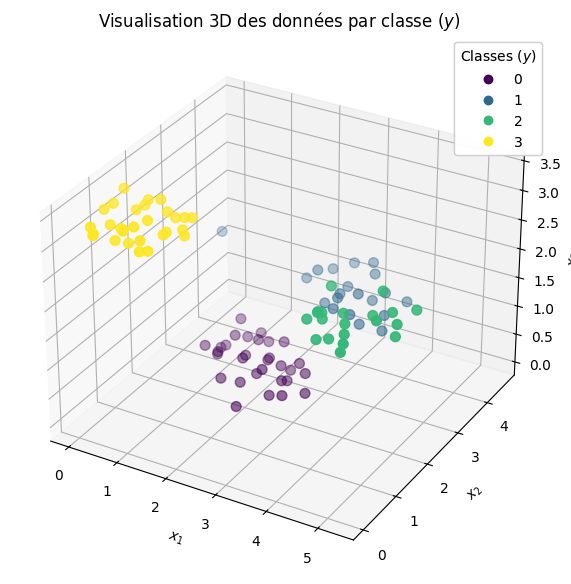

In [173]:
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(df['x1'], 
                     df['x2'], 
                     df['x3'], 
                     c=df['y'],      
                     cmap='viridis', 
                     s=50)           

ax.set_xlabel('$x_1$')
ax.set_ylabel('$x_2$')
ax.set_zlabel('$x_3$')
plt.title('Visualisation 3D des données par classe ($y$)')

legend = ax.legend(*scatter.legend_elements(), title="Classes ($y$)")
ax.add_artist(legend)

plt.show()

# 3. Feed forward propagation

In [174]:
df.shape

(99, 4)

## Dimension
Parameters:  
- $N = 3$,  
- $I = 99$,  
- $J = 4$,  
- $K = 6$ (TBD)
- $\alpha_1 = \alpha_2 = 10^{-3}$
- $\epsilon = 10^{-2}$

Matrices :  
- $V \in \mathbb{R}^{(N+1) \times K}$
- $W \in \mathbb{R}^{(K+1) \times J}$
- $X \in \mathbb{R}^{I \times N}$
- $\overline{X} \in \mathbb{R}^{I \times (N+1)}$
- $Y \in \mathbb{R}^{I}$

In [175]:
N = df.shape[1] - 1
I = df.shape[0]
J = df['y'].nunique()
K = 6
learning_rate = 0.1 # alpha
epsilon = pow(10,-4) # threshold
iter = 0 # iteration
delta_E = 10000
E = []
E.append(delta_E)

## Random $\theta$ initialisation

In [176]:
rng = np.random.default_rng()

V = rng.random((N+1, K))
W = rng.random((K+1, J))

print(V)

[[0.06761899 0.52050842 0.08685626 0.470043   0.7699965  0.15444958]
 [0.73165759 0.21112056 0.29299315 0.25306301 0.13649505 0.73759247]
 [0.76557821 0.02988348 0.32961199 0.61397187 0.03812388 0.27441451]
 [0.29884097 0.90613729 0.81304732 0.04523249 0.11533097 0.88819601]]


## Read the data (creation of $X$ and $\overline{X}$)

creation of $X \in \mathbb{R}^{I \times N}$

In [177]:
X = df[['x1','x2','x3']].values
print(X.shape)

(99, 3)


we know that $X_0 = 1$ then we can create $\overline{X} \in \mathbb{R}^{I \times (N+1)}$

In [178]:
X_bar = np.insert(X, 0, 1, axis=1)
print(X_bar.shape)

(99, 4)


## Activation function

In [179]:
def sigmoid(X):
    return 1 / (1 + np.exp(-X))

## Feed Forward Propagation

In [180]:
def fwp(X_bar, F_bar, V, W):
    X_bar_bar = X_bar @ V
    F = sigmoid(X_bar_bar)
    F_bar = np.insert(F, 0, 1, axis=1)
    F_bar_bar = F_bar @ W
    G = sigmoid(F_bar_bar)
    return G, F_bar, F

## One-Hot encoding for the $Y$

We have $Y \in \mathbb{R}^{I}$ and we want to have $Y' \in \mathbb{R}^{I \times J}$

In [181]:
def one_hot_encoding(Y, I, J):
    Y_prime = np.zeros((I, J))
    for i in range(I): 
        value_class = int(Y[i])
        Y_prime[i][value_class] = 1
    return Y_prime

## Error computation

We have the error sucha as  
$$E \triangleq \frac{1}{2} \sum_{i=1}^{I} {\lVert g^{(i)} - y^{(i)} \rVert}_{2}^{2} = \frac{1}{2} \sum_{i=1}^{I} \sum_{j=1}^{J}  ( g^{(i)}_{j} - y^{(i)}_{j} )² $$

We have $G \in \mathbb{R}^{I \times J}$ and $Y' \in \mathbb{R}^{I \times J}$

In [182]:
def error(G, Y_prime, I, J):
    E = 0
    for i in range(I):
        for j in range(J):
            E += pow((G[i][j] - Y_prime[i][j]), 2)
    E = (1/2) * E
    return E

## Back propagation

Derivative of the error are :  
$$ \frac{\partial E}{\partial W_{kj}} = \sum_{i=1}^{I} (g_{j}^{(i)} - y_{j}^{(i)}) g_{j}^{(i)} (1 - g_{j}^{(i)}) f_{k}^{(i)}$$
and we have,  
$$\frac{\partial E}{\partial V_{nk}} = \sum_{i=1}^{I} \sum_{j=1}^{J} (g_{j}^{(i)} - y_{j}^{(i)}) g_{j}^{(i)} (1 - g_{j}^{(i)}) W_{kj} f_{k}^{(i)} (1 - f_{k}^{(i)}) X_{n}^{(i)}$$

In [183]:
def dE_dW_kj(k, j, I, G, Y_prime, F_bar):
    res = 0
    for i in range(I):
        res += (G[i][j] - Y_prime[i][j]) * G[i][j] * (1 - G[i][j]) * F_bar[i][k]
    return res

def dE_dW_nk(n, k, J, I, G, Y_prime, F, X_bar):
    res = 0
    for i in range(I):
        for j in range(J):
            res += (G[i][j] - Y_prime[i][j]) * G[i][j] * (1 - G[i][j]) * W[k+1][j] * F[i][k] * (1-F[i][k]) * X_bar[i][n]
    return res

For $k \in \llbracket 0,K \rrbracket$, $j \in \llbracket 1,J \rrbracket$ :
$$W_{kj}^{(\text{iter})} = W_{kj}^{(\text{iter} - 1)} - \alpha_{1} \frac{\partial E}{\partial W_{kj}^{(\text{iter} - 1)}}$$
And for $n \in \llbracket 0,N \rrbracket$, $k \in \llbracket 1,K \rrbracket$ :
$$V_{nk}^{(\text{iter})} = V_{nk}^{(\text{iter} - 1)} - \alpha_{2} \frac{\partial E}{\partial V_{nk}^{(\text{iter} - 1)}}$$

In [184]:
def back_prop(K, J, N, G, Y_prime, F_bar, F, learning_rate, X_bar, V, W):

    grad_W = np.zeros_like(W)
    grad_V = np.zeros_like(V)

    for k in range(K+1):
        for j in range(J):
            grad_W[k][j] = dE_dW_kj(k,j, I, G, Y_prime, F_bar)

    for n in range(N+1):
        for k in range(K):
            grad_V[n][k] = dE_dW_nk(n, k, J, I, G, Y_prime, F, X_bar)

    W = W - learning_rate * grad_W
    V = V - learning_rate * grad_V
    return V,W

In [185]:
Y_prime = one_hot_encoding(df['y'].values, I, J)
G, F_bar, F = fwp(X_bar, None, V, W)
E = [error(G, Y_prime, I, J)]
delta_E = 100000
plot_E = []

while (abs(delta_E) > epsilon):
    old_E = E[-1]
    V, W = back_prop(K, J, N, G, Y_prime, F_bar, F, learning_rate, X_bar, V, W)
    G, F_bar, F = fwp(X_bar, None, V, W)
    current_E = error(G, Y_prime, I, J)
    E.append(current_E)
    delta_E = current_E - old_E
    iter += 1
    #print(f"{iter}, SSE: {current_E}")
    plot_E.append(current_E)
    if (iter > 500):
        break

## Plot the training error

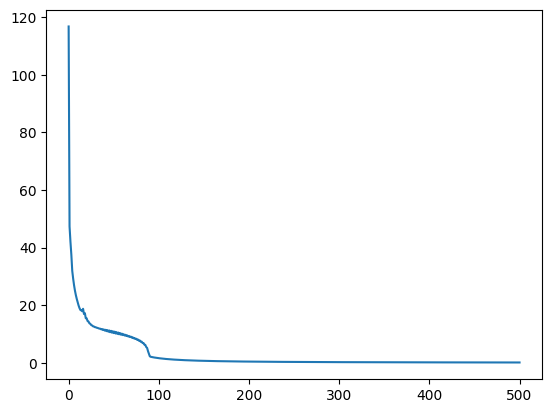

In [186]:
plt.figure()
plt.plot(plot_E)
plt.show()

## Predictions

For classification problems we have :  
$$\hat{y}_{j}^{(i)} = \underset{j \in [1,\ldots ,J]}{\operatorname{arg\,max}} \, g_{j}^{(i)}$$

In [187]:
def prediction(X, V, W):
    X_bar = np.insert(X,0,1,axis=1)
    G, _, _ = fwp(X_bar, None, V, W)
    predict = np.argmax(G, axis=1)
    return predict, G

In [188]:
X_inference = [[2,	2,	0.15], [3.4,	4,	1],[5.3,	2,	2],[1.3,	1,	3]]
p, g = prediction(X_inference, V,W)
np.set_printoptions(precision=3, suppress=True)
print(p)
print(g)

[0 1 2 3]
[[0.969 0.031 0.009 0.009]
 [0.053 0.941 0.019 0.003]
 [0.001 0.033 0.976 0.014]
 [0.    0.006 0.021 0.98 ]]


## $V^*$ and $W^*$

In [189]:
np.set_printoptions(precision=8, suppress=False)

In [190]:
print(W)
print("Shape: ",W.shape)

[[ 1.63377599 -3.45598043 -1.20767835 -1.57876574]
 [ 0.36336238 -1.62990602  0.86260555 -2.49286334]
 [-1.05767566 -1.86989962 -3.60396788  3.73182152]
 [-1.74317597 -5.07318588  3.26077229  0.63747683]
 [ 1.72606472  1.69597083 -4.55127926 -0.88909881]
 [-0.18073694 -1.63126073 -2.78330703  3.07029921]
 [-7.05217694  6.60454345  0.97773673 -0.79997127]]
Shape:  (7, 4)


In [191]:
print(V)
print("Shape: ", V.shape)

[[-0.01124558  0.44516807 -0.48346909  1.19677535  1.05224855 -4.7565553 ]
 [ 1.38567824 -1.65663027  0.82890144 -1.66835557 -1.40446193  0.28061759]
 [ 0.55236428 -1.30769885 -2.85748505  2.61899387 -0.88293861 -0.44274921]
 [-1.26468274  1.9595137   2.60456974 -0.93141291  1.33274407  8.25161089]]
Shape:  (4, 6)


## Inference

In [192]:
X_inference = [[0,	0,	3], [2,	2,	0],[4,	4,	1],[4.5,	1.5,	2]]
p, g = prediction(X_inference, V,W)
np.set_printoptions(precision=3, suppress=True)
print(p)
print(g)

[3 0 1 2]
[[0.    0.006 0.017 0.992]
 [0.973 0.029 0.008 0.008]
 [0.049 0.943 0.02  0.003]
 [0.001 0.03  0.976 0.016]]


## Plot in 3D test and training datas

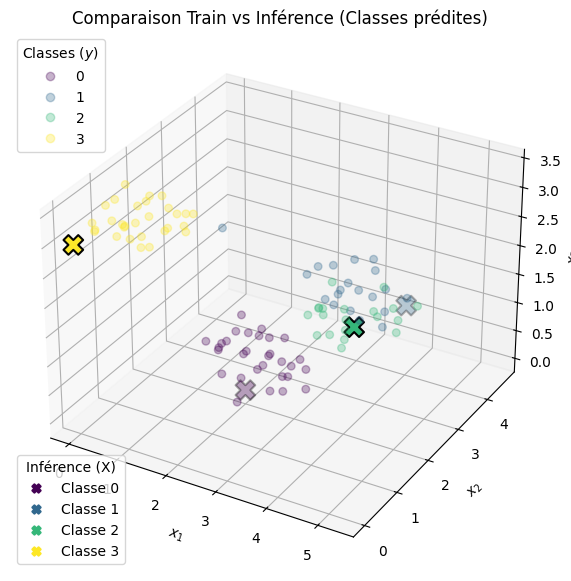

In [193]:
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(df['x1'], df['x2'], df['x3'], 
                     c=df['y'], cmap='viridis', s=30, alpha=0.3, label='Train')

X_inference_np = np.array(X_inference)

scatter_test = ax.scatter(X_inference_np[:, 0], 
                          X_inference_np[:, 1], 
                          X_inference_np[:, 2], 
                          c=p, cmap='viridis', s=200, marker='X', 
                          edgecolors='black', linewidths=1.5, label='Inférence')

ax.set_xlabel('$x_1$')
ax.set_ylabel('$x_2$')
ax.set_zlabel('$x_3$')
plt.title('Comparaison Train vs Inférence (Classes prédites)')

legend1 = ax.legend(*scatter.legend_elements(), title="Classes ($y$)", loc="upper left")
ax.add_artist(legend1)

ax.legend(handles=scatter_test.legend_elements()[0], labels=["Classe 0", "Classe 1", "Classe 2", "Classe 3"], 
          title="Inférence (X)", loc="lower left")

plt.show()

# Task 2 - Regression

In [42]:
df_r = pd.read_csv('data_regression.txt', sep='\s+')
print(df_r.head())

          x         y
0  1.000000  0.141764
1  1.080808  0.117693
2  1.161616  0.135916
3  1.242424  0.139246
4  1.323232  0.136328


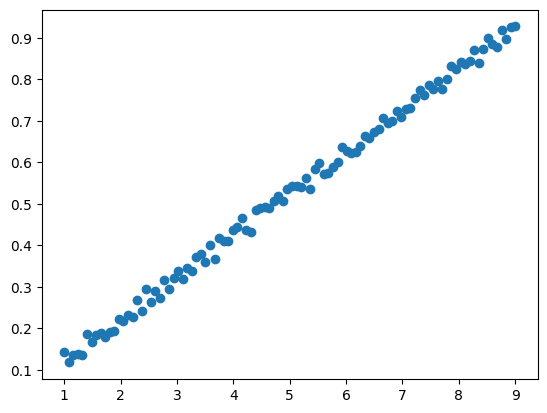

In [45]:
plt.figure()
plt.scatter(df_r['x'], df_r['y'])
plt.show()

## Feed Forward FFNN  
We use the same piece of codes in the classification problems.

## Train test split

In [85]:
X_train = df_r['x'].iloc[0:70]
X_test = df_r['x'].iloc[70:100]
Y_test = df_r['y'].iloc[70:100]
Y_train = df_r['y'].iloc[0:70]

We extend the dimensions because we had some error $(70,) \neq (70,1)$

In [86]:
X_train = np.expand_dims(X_train, axis=1)
X_test = np.expand_dims(X_test, axis=1)
Y_train = np.expand_dims(Y_train, axis=1)
Y_test = np.expand_dims(Y_test, axis=1)

In [93]:
print("X_train : ",X_train.shape)
print("X_test : ",X_test.shape)
print("Y_train : ",Y_train.shape)
print("Y_test : ",Y_test.shape)

X_train :  (70, 1)
X_test :  (30, 1)
Y_train :  (70, 1)
Y_test :  (30, 1)


In [94]:
X_bar = np.insert(X_train, 0, 1, axis=1)
print(X_bar.shape)

(70, 2)


## Hyperparameters

In [162]:
N = X_train.shape[1]
I = X_train.shape[0]
J = 1
K = 6
learning_rate_r = 0.1 # alpha
epsilon_r = pow(10,-3) # threshold
iter_r = 0 # iteration
delta_E_r = 10000
E_r = []
E_r.append(delta_E_r)

## Initialize $\theta$ randomly

In [163]:
rng = np.random.default_rng()

V_r = rng.random((N+1, K))
W_r = rng.random((K+1, J))

print(V_r)
print(W_r)

[[0.24468844 0.08733369 0.6110733  0.56164097 0.39146068 0.64737117]
 [0.54471931 0.21588813 0.26296806 0.13032704 0.73836961 0.71001702]]
[[0.72411527]
 [0.53346084]
 [0.3174869 ]
 [0.1883338 ]
 [0.56830524]
 [0.46384799]
 [0.53147091]]


## Training

In [164]:
G, F_bar, F = fwp(X_bar, None, V_r, W_r)
E_r = [error(G, Y_train, I, J)]
delta_E_r = 100000
plot_E_r = []
plot_E_r_10 = []

while (abs(delta_E_r) > epsilon_r):
    old_E = E[-1]
    V_r, W_r = back_prop(K, J, N, G, Y_train, F_bar, F, learning_rate_r, X_bar, V_r, W_r)
    G, F_bar, F = fwp(X_bar, None, V_r, W_r)
    current_E = error(G, Y_train, I, J)
    E.append(current_E)
    delta_E = current_E - old_E
    iter_r += 1
    print(f"{iter_r}, SSE: {current_E}")
    plot_E_r.append(current_E)
    if (iter_r%10 == 0):
        plot_E_r_10.append(current_E)
    if (iter_r > 600):
        break

1, SSE: 8.574982881723347
2, SSE: 1.3742672116957773
3, SSE: 1.4323756685866171
4, SSE: 1.2509698226595383
5, SSE: 1.2926013327820882
6, SSE: 1.20691891155835
7, SSE: 1.241664507781011
8, SSE: 1.1809553453021437
9, SSE: 1.2120678187400642
10, SSE: 1.162336507403044
11, SSE: 1.1913500091757845
12, SSE: 1.1473077061154806
13, SSE: 1.1750607143937546
14, SSE: 1.1341632653783027
15, SSE: 1.161149845756926
16, SSE: 1.1220003253161468
17, SSE: 1.1485210009310354
18, SSE: 1.1102908938644536
19, SSE: 1.1365281427060716
20, SSE: 1.0987058565691248
21, SSE: 1.1247667015243108
22, SSE: 1.0870330818998415
23, SSE: 1.1129756010549758
24, SSE: 1.0751354133582551
25, SSE: 1.1009865563203731
26, SSE: 1.0629271145343528
27, SSE: 1.088695305212729
28, SSE: 1.0503594184067624
29, SSE: 1.0760436834776543
30, SSE: 1.0374108259602315
31, SSE: 1.063007380741677
32, SSE: 1.024080043176752
33, SSE: 1.0495868888408306
34, SSE: 1.0103805125097844
35, SSE: 1.0358004236089289
36, SSE: 0.9963360176180808
37, SSE: 1

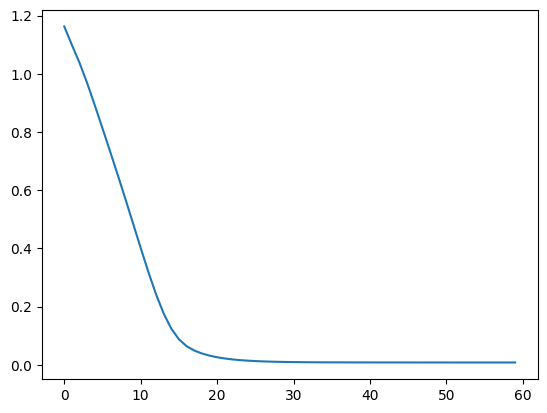

In [165]:
plt.figure()
plt.plot(plot_E_r_10)
plt.show()

## $V^*$ and $W^*$

In [166]:
print(W_r)
print("Shape: ",W_r.shape)

[[-2.492962  ]
 [ 2.33741355]
 [ 0.80984729]
 [-0.05327514]
 [-1.72234595]
 [ 0.97123214]
 [ 0.11268647]]
Shape:  (7, 1)


In [167]:
print(V)
print("Shape: ",V.shape)

[[ 0.37131205  0.3425754   0.63897631  0.62871338  0.20932054  0.78971159]
 [ 0.54066675  0.0792569   0.34697762  0.7483899  -0.02437902 -0.01609336]]
Shape:  (2, 6)


## Inference

In [168]:
def prediction_r(X, V, W):
    X_bar = np.insert(X,0,1,axis=1)
    #X_bar = np.expand_dims(X_bar, axis=1)
    G, _, _ = fwp(X_bar, None, V, W)
    return G

In [169]:
X_inference_r = [[6.818181818181818343]]
g = prediction_r(X_inference_r, V_r,W_r)
np.set_printoptions(precision=8, suppress=False)

print(g)

[[0.67094422]]
